<a href="https://colab.research.google.com/github/albinsaidach1441-source/Artificial_Intelligent/blob/Praktikum_1/linear_regresion_berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
data = {
    'inflasi': [2,3,4,5,6,7,8,9,10,11],
    'suku_bunga': [5,5.5,6,6.5,7,7.5,8,8.5,9,9.5],
    'nilai_tukar': [14000,14200,14400,14600,14800,15000,15200,15400,15600,15800],
    'daya_beli': [95,90,85,80,75,70,65,60,55,50]
}

df = pd.DataFrame(data)
print(df)


   inflasi  suku_bunga  nilai_tukar  daya_beli
0        2         5.0        14000         95
1        3         5.5        14200         90
2        4         6.0        14400         85
3        5         6.5        14600         80
4        6         7.0        14800         75
5        7         7.5        15000         70
6        8         8.0        15200         65
7        9         8.5        15400         60
8       10         9.0        15600         55
9       11         9.5        15800         50


In [3]:
# menentukan variabel
X = df[['inflasi', 'suku_bunga', 'nilai_tukar']]
y = df['daya_beli']

In [4]:
# split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# membuat model regresi
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
# melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 → pengaruh jam belajar
# b2 → pengaruh kehadiran
# b3 → pengaruh motivasi

Intercept (a): 444.98962532420876
Koefisien (b1, b2, b3): [-1.24996094e-04 -6.24980469e-05 -2.49992188e-02]


In [9]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Daya Beli Asli:", y_test.values)

Prediksi: [55. 90.]
Daya Beli Asli: [55 90]


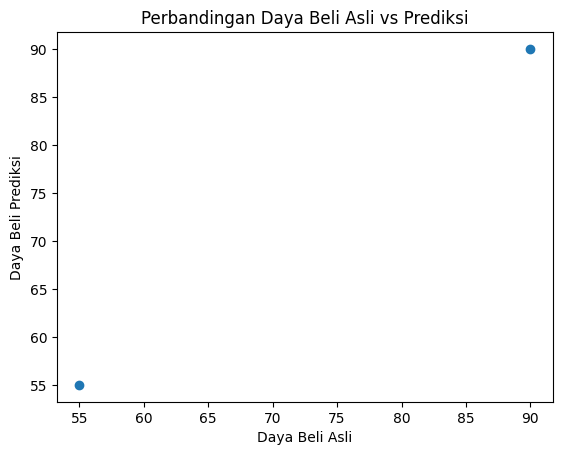

In [10]:
plt.scatter(y_test, y_pred)
plt.xlabel("Daya Beli Asli")
plt.ylabel("Daya Beli Prediksi")
plt.title("Perbandingan Daya Beli Asli vs Prediksi")
plt.show()

In [12]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.0
MSE: 0.0
RMSE: 0.0


In [13]:
data_baru = [[12, 10, 16000]]
prediksi = model.predict(data_baru)

print("Prediksi daya beli untuk (inflasi=12%, suku_bunga=10%, nilai_tukar=16000):", prediksi[0])

Prediksi daya beli untuk (inflasi=12%, suku_bunga=10%, nilai_tukar=16000): 45.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
# ANALISIS
print("\n" + "="*60)
print("ANALISIS REGRESI LINEAR BERGANDA")
print("="*60)
print(f"""
1. Persamaan Regresi:
   Daya Beli = {model.intercept_:.2f} + ({model.coef_[0]:.2f} x Inflasi) + ({model.coef_[1]:.2f} x Suku_Bunga) + ({model.coef_[2]:.2f} x Nilai_Tukar)

2. Interpretasi Koefisien:
   - Inflasi: setiap +1% inflasi, daya beli turun {abs(model.coef_[0]):.2f} poin
   - Suku Bunga: setiap +1% suku bunga, daya beli turun {abs(model.coef_[1]):.2f} poin
   - Nilai Tukar: setiap +100 rupiah, daya beli turun {abs(model.coef_[2]*100):.2f} poin

3. Variabel Paling Berpengaruh:
   { 'Inflasi' if abs(model.coef_[0]) > abs(model.coef_[1]) and abs(model.coef_[0]) > abs(model.coef_[2]) else 'Suku Bunga' if abs(model.coef_[1]) > abs(model.coef_[2]) else 'Nilai Tukar' }

4. Kualitas Model:
   - R-Squared = {model.score(X_test, y_test):.4f} ({model.score(X_test, y_test)*100:.1f}%)
   - RMSE = {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.2f}

5. Kesimpulan Ekonomi:
   - Inflasi yang tinggi menurunkan daya beli masyarakat
   - Suku bunga yang naik menurunkan daya beli
   - Pelemahan rupiah (nilai tukar naik) menurunkan daya beli
   - Ketiga variabel makroekonomi ini berpengaruh negatif terhadap daya beli
""")


ANALISIS REGRESI LINEAR BERGANDA

1. Persamaan Regresi:
   Daya Beli = 444.99 + (-0.00 x Inflasi) + (-0.00 x Suku_Bunga) + (-0.02 x Nilai_Tukar)

2. Interpretasi Koefisien:
   - Inflasi: setiap +1% inflasi, daya beli turun 0.00 poin
   - Suku Bunga: setiap +1% suku bunga, daya beli turun 0.00 poin
   - Nilai Tukar: setiap +100 rupiah, daya beli turun 2.50 poin

3. Variabel Paling Berpengaruh:
   Nilai Tukar

4. Kualitas Model:
   - R-Squared = 1.0000 (100.0%)
   - RMSE = 0.00

5. Kesimpulan Ekonomi:
   - Inflasi yang tinggi menurunkan daya beli masyarakat
   - Suku bunga yang naik menurunkan daya beli
   - Pelemahan rupiah (nilai tukar naik) menurunkan daya beli
   - Ketiga variabel makroekonomi ini berpengaruh negatif terhadap daya beli

